In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("data.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  object 
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  object 
 5   PaymentMethod       100000 non-null  object 
 6   StoreLocation       100000 non-null  object 
 7   ProductCategory     100000 non-null  object 
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 7.6+ MB


In [ ]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Preview first 5 rows
print(df.head())

# Check missing values
print(df.isnull().sum())

Dataset shape: (100000, 10)
   CustomerID ProductID  Quantity      Price   TransactionDate PaymentMethod  \
0      109318         C         7  80.079844  12/26/2023 12:32          Cash   
1      993229         C         4  75.195229     8/5/2023 0:00          Cash   
2      579675         A         8  31.528816   3/11/2024 18:51          Cash   
3      799826         D         5  98.880218  10/27/2023 22:00        PayPal   
4      121413         A         7  93.188512  12/22/2023 11:38          Cash   

                                       StoreLocation ProductCategory  \
0            176 Andrew Cliffs\nBaileyfort, HI 93354           Books   
1  11635 William Well Suite 809\nEast Kara, MT 19483      Home Decor   
2  910 Mendez Ville Suite 909\nPort Lauraland, MO...           Books   
3  87522 Sharon Corners Suite 500\nLake Tammy, MO...           Books   
4   0070 Michelle Island Suite 143\nHoland, VA 80142     Electronics   

   DiscountApplied(%)  TotalAmount  
0           18.677100

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['customerid', 'productid', 'quantity', 'price', 'transactiondate',
       'paymentmethod', 'storelocation', 'productcategory',
       'discountapplied(%)', 'totalamount'],
      dtype='object')


In [ ]:
df = df.rename(columns={
    'customerid': 'customer_id',
    'productid': 'product_id',
    'transactiondate': 'transaction_date',
    'paymentmethod': 'payment_method',
    'storelocation': 'store_location',
    'productcategory': 'product_category',
    'discountapplied(%)': 'discount',
    'totalamount': 'total_amount'
})

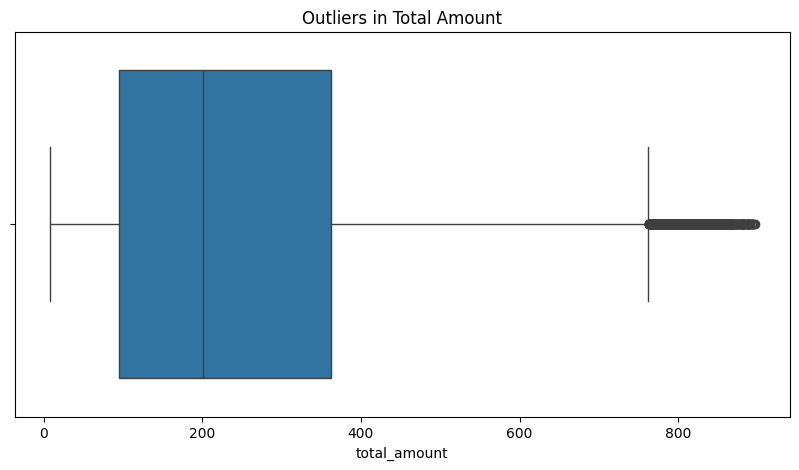

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x=df['total_amount'])
plt.title("Outliers in Total Amount")
plt.show()

Detect Outliers

In [ ]:
#Using IQR method
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-305.10642370624987 762.2798220637499


In [ ]:
df = df[(df['total_amount'] >= lower_bound) &
        (df['total_amount'] <= upper_bound)]
#Apply to other columns
cols = ['quantity', 'price', 'total_amount']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
#Outliers
print(df.shape)

(98978, 10)


In [ ]:
# Ensure date format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create reference date
today = df['transaction_date'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('customer_id').agg({
    'transaction_date': lambda x: (today - x.max()).days,
    'customer_id': 'count',
    'total_amount': 'sum'
})

# Rename columns
rfm.columns = ['recency', 'frequency', 'monetary']
rfm.reset_index(inplace=True)

print(rfm.head())

   customer_id  recency  frequency    monetary
0           14      267          1  256.232791
1           42      346          1  502.656523
2           49      329          1   21.399047
3           59       28          2  249.492696
4           65      316          1  548.006625


In [ ]:
rfm['avg_spend'] = df.groupby('customer_id')['total_amount'].mean().values
rfm['discount_usage'] = df.groupby('customer_id')['discount'].mean().values
rfm['category_count'] = df.groupby('customer_id')['product_category'].nunique().values
features = rfm[['recency', 'frequency', 'monetary',
                'avg_spend', 'discount_usage', 'category_count']]

In [ ]:
df.to_csv("processed_data.csv", index=False)

In [ ]:
import os
print(os.listdir())

['.config', 'data', 'data.csv', '.ipynb_checkpoints', 'processed_data.csv', 'sample_data']


In [ ]:
from google.colab import files
files.download("processed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>